In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("D:\\Data\\Advertising.csv")

In [3]:
df.head()

,TV,radio,newspaper,sales
0,230100,37800,69200,22100
1,44500,39300,45100,10400
2,17200,45900,69300,9300
3,151500,41300,58500,18500
4,180800,10800,58400,12900


In [4]:
df.columns

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

In [5]:
df.shape

(200, 4)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   TV         200 non-null    int64
 1   radio      200 non-null    int64
 2   newspaper  200 non-null    int64
 3   sales      200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [7]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147042.500000,23264.000000,30554.000000,14022.500000
std,85854.236315,14846.809176,21778.620839,5217.456566
min,700.000000,0.000000,300.000000,1600.000000
25%,74375.000000,9975.000000,12750.000000,10375.000000
50%,149750.000000,22900.000000,25750.000000,12900.000000
75%,218825.000000,36525.000000,45100.000000,17400.000000
max,296400.000000,49600.000000,114000.000000,27000.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [10]:
df.dtypes

TV           int64
radio        int64
newspaper    int64
sales        int64
dtype: object

In [11]:
df.columns

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

In [12]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


In [13]:
corr = df.corr(numeric_only=True)

print(
    corr["sales"]
    .drop("sales")
    .sort_values(ascending=False)
)

TV           0.782224
radio        0.576223
newspaper    0.228299
Name: sales, dtype: float64


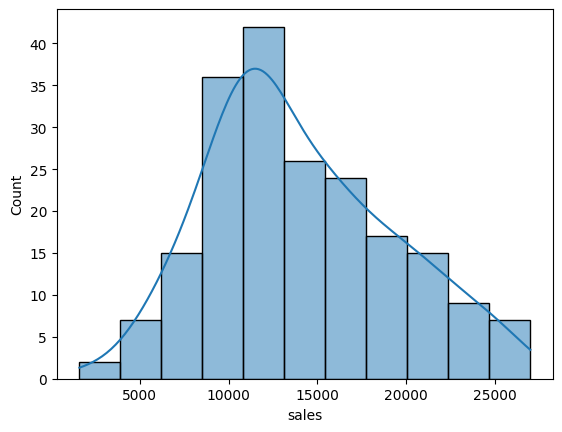

In [14]:
sns.histplot(df["sales"], kde=True)
plt.show()

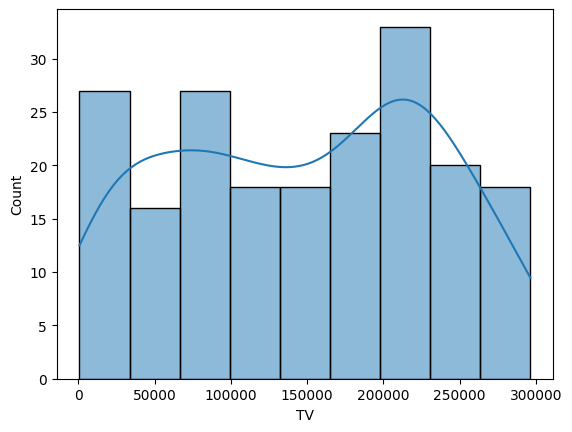

In [15]:
sns.histplot(df["TV"], kde=True)
plt.show()		

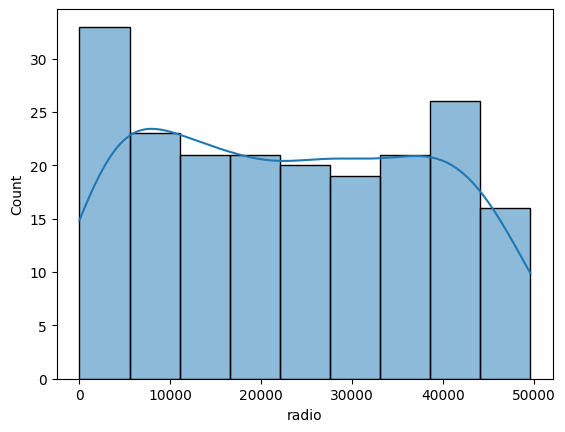

In [16]:
sns.histplot(df["radio"], kde=True)
plt.show()

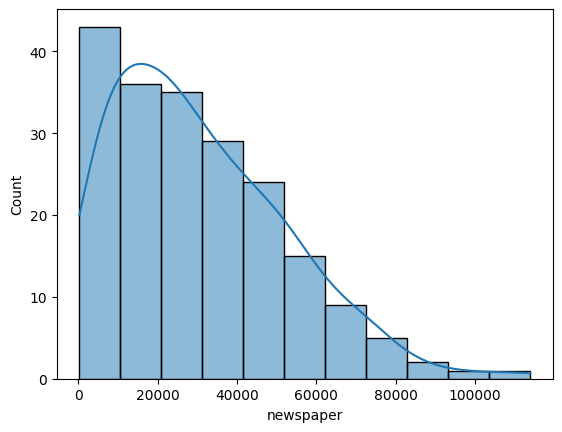

In [17]:
sns.histplot(df["newspaper"], kde=True)
plt.show()

In [18]:
df["sqrt_newspaper"] = np.sqrt(df["newspaper"])

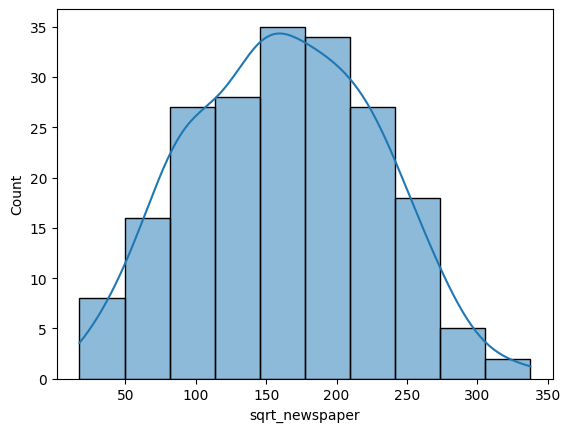

In [19]:
sns.histplot(df["sqrt_newspaper"], kde=True)
plt.show()

In [20]:
df = df.drop(columns=["newspaper"])

In [21]:
df.head()

,TV,radio,sales,sqrt_newspaper
0,230100,37800,22100,263.058929
1,44500,39300,10400,212.367606
2,17200,45900,9300,263.248932
3,151500,41300,18500,241.867732
4,180800,10800,12900,241.660919


<Axes: >

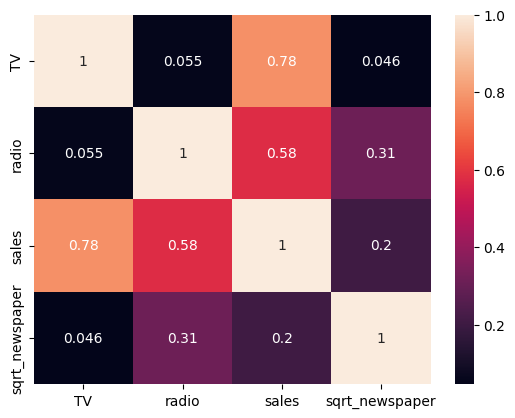

In [22]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

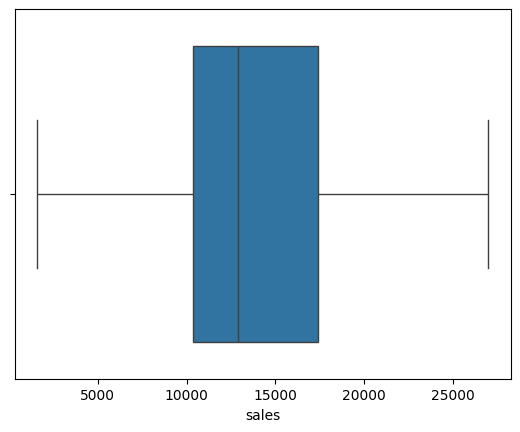

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["sales"])

plt.show()

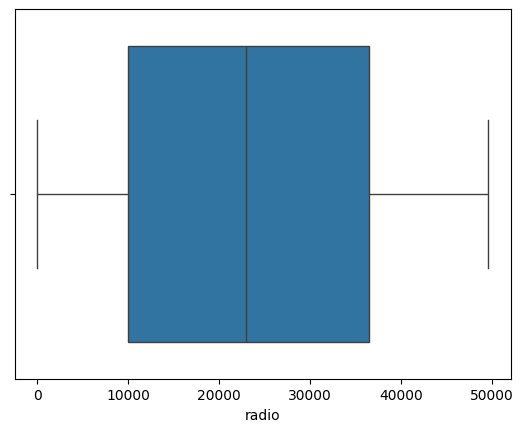

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["radio"])

plt.show()

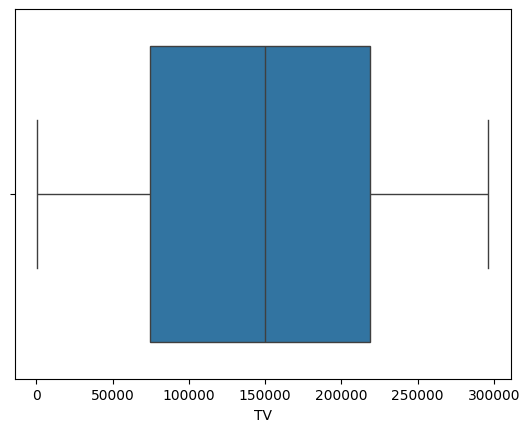

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["TV"])

plt.show()

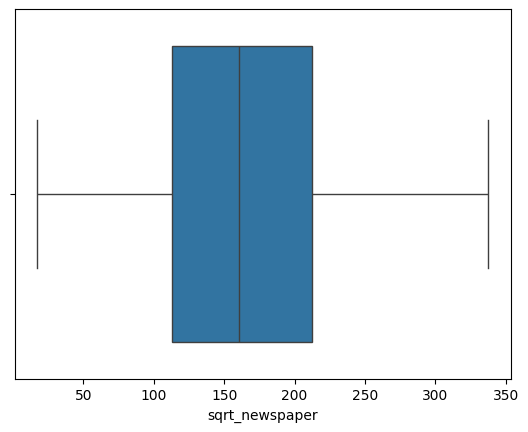

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["sqrt_newspaper"])

plt.show()

In [27]:
x=df.drop('sales',axis =1)
y=df['sales']

In [28]:
x

,TV,radio,sqrt_newspaper
0,230100,37800,263.058929
1,44500,39300,212.367606
2,17200,45900,263.248932
3,151500,41300,241.867732
4,180800,10800,241.660919
...,...,...,...
195,38200,3700,117.473401
196,94200,4900,90.000000
197,177000,9300,80.000000
198,283600,42000,257.293607


In [29]:
y

0      22100
1      10400
2       9300
3      18500
4      12900
       ...  
195     7600
196     9700
197    12800
198    25500
199    13400
Name: sales, Length: 200, dtype: int64

In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
X_train_scaled

array([[-4.04248386e-01, -1.02823707e+00, -1.59124112e-01],
       [ 3.20607716e-01, -9.19827737e-01, -1.33041925e+00],
       [-1.27051084e+00,  2.59123702e-01,  4.16267503e-01],
       [-1.04235941e+00, -6.96233499e-01, -4.31001287e-01],
       [ 8.79103401e-01, -1.38734296e+00, -5.99853722e-01],
       [-1.32873699e+00, -1.29926038e+00, -7.20690973e-01],
       [-9.43731452e-01, -4.65863678e-01,  6.54476965e-01],
       [-3.23140256e-02,  6.94073782e-02, -3.83404543e-01],
       [-5.39713297e-01, -1.16374872e+00,  3.85717633e-01],
       [-8.75998996e-01,  3.13328366e-01, -5.73964239e-01],
       [-8.53421511e-01,  1.62101588e+00,  3.90100807e-01],
       [ 2.18414888e-01, -1.06889056e+00, -7.91247009e-01],
       [-1.67928215e+00,  1.76330312e+00,  1.82389017e+00],
       [-1.68997675e+00,  1.08574483e+00,  1.02796613e+00],
       [-8.74810708e-01, -1.49575229e+00, -6.52648263e-01],
       [-2.45017701e-01, -1.16374872e+00,  2.46530788e-01],
       [-9.10459368e-01, -3.98107848e-01

In [33]:
X_test_scaled 

array([[ 0.15781217,  0.59112727,  1.11022499],
       [ 0.53925283,  1.68199613,  1.11022499],
       [ 1.69783431,  0.36753303,  0.74975969],
       [-1.64363349,  0.95023317,  0.82715771],
       [ 0.83513672,  1.77007871, -1.71167159],
       [-0.89025846,  0.82149709,  1.10314396],
       [ 0.79354661,  1.42452397,  0.05137956],
       [-1.18851892, -0.76398933, -0.42499556],
       [ 0.86009078, -1.31958713, -0.7697995 ],
       [ 0.29803023, -0.02545078,  0.25571303],
       [-1.40835233,  0.11683646, -1.86892043],
       [-1.11484502, -1.16374872,  0.17199057],
       [ 1.00387371, -1.31958713,  2.10607936],
       [-1.71849568,  0.47594236, -1.05456792],
       [-0.12500054, -1.40766971,  0.02161735],
       [ 0.23980408, -1.02146148,  0.42060681],
       [-1.69591819,  0.35398186,  0.67855475],
       [ 0.56539519,  0.02875388, -0.69318733],
       [-0.88788188, -0.17451361,  0.30119314],
       [ 1.03833409,  0.31332837, -0.92558332],
       [ 0.94445928,  0.63855635,  1.800

In [34]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

In [35]:
from sklearn.linear_model import Ridge

ridge_model = Ridge()

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

In [36]:
from sklearn.linear_model import Lasso

lasso_model = Lasso()

lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

In [37]:
from sklearn.linear_model import ElasticNet

elastic_model = ElasticNet()

elastic_model.fit(X_train_scaled, y_train)

y_pred_elastic = elastic_model.predict(X_test_scaled)

In [38]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

In [39]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [40]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

In [41]:
from sklearn.ensemble import ExtraTreesRegressor

et_model = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)

et_model.fit(X_train_scaled, y_train)

y_pred_et = et_model.predict(X_test_scaled)

In [42]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [43]:
from sklearn.ensemble import AdaBoostRegressor

ada_model = AdaBoostRegressor(random_state=42)

ada_model.fit(X_train_scaled, y_train)

y_pred_ada = ada_model.predict(X_test_scaled)

In [44]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

y_pred_et = xgb_model.predict(X_test_scaled)

In [45]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

models = {
    "Linear Regression": y_pred_lr,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "elastic_model": y_pred_elastic,

    "poly_model": y_pred_poly,
    
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "et_model": y_pred_et,

    
    "Gradient Boosting": y_pred_gb,
    "AdaBoost": y_pred_ada,
    "xgb_model":y_pred_et
}

for name, y_pred in models.items():

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print(name)
    print("R2   :", r2)
    print("MAE  :", mae)
    print("MSE  :", mse)
    print("RMSE :", rmse)
    print("-" * 40)

Linear Regression
R2   : 0.8994550077374865
MAE  : 1465.053794541546
MSE  : 3173561.2893708698
RMSE : 1781.4492104381955
----------------------------------------
Ridge
R2   : 0.8989023540485844
MAE  : 1467.859033550196
MSE  : 3191005.025891812
RMSE : 1786.3384410272909
----------------------------------------
Lasso
R2   : 0.8994535744625821
MAE  : 1464.8800458408
MSE  : 3173606.5286776824
RMSE : 1781.4619077256978
----------------------------------------
elastic_model
R2   : 0.7895609259127714
MAE  : 2028.6456509750606
MSE  : 6642213.443615436
RMSE : 2577.2492009146954
----------------------------------------
poly_model
R2   : 0.9860643028974906
MAE  : 527.6427358653706
MSE  : 439860.68196665944
RMSE : 663.2199348381045
----------------------------------------
Decision Tree
R2   : 0.9498868851079418
MAE  : 907.5
MSE  : 1581750.0
RMSE : 1257.676428975275
----------------------------------------
Random Forest
R2   : 0.9812332103342953
MAE  : 623.925
MSE  : 592347.325
RMSE : 769.641036457

In [46]:
print(type(et_model))
print(type(xgb_model))

y_pred_et = et_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

print(np.array_equal(y_pred_et, y_pred_xgb))

<class 'sklearn.ensemble._forest.ExtraTreesRegressor'>
<class 'xgboost.sklearn.XGBRegressor'>
False


In [47]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    et_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("CV R² scores:", scores)
print("Mean CV R²:", scores.mean())

CV R² scores: [0.98646556 0.98377019 0.99407334 0.98855622 0.96765803]
Mean CV R²: 0.9841046674898124


In [48]:
print("Extra Trees predictions:")
print(y_pred_et[:10])

print("\nXGBoost predictions:")
print(y_pred_xgb[:10])

Extra Trees predictions:
[26330. 26330. 26330. 26330. 26330. 26330. 26330. 26330. 26330. 26330.]

XGBoost predictions:
[26556.36 26556.36 26556.36 26556.36 26556.36 26556.36 26556.36 26556.36
 26556.36 26556.36]


In [49]:
import numpy as np

difference = np.abs(y_pred_et - y_pred_xgb)

print("Maximum difference:", difference.max())
print("Mean difference:", difference.mean())

Maximum difference: 226.359375
Mean difference: 226.359375


In [50]:
print("Extra Trees:")
print(et_model.get_params())

print("\nXGBoost:")
print(xgb_model.get_params())

Extra Trees:
{'bootstrap': False, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

XGBoost:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_we

In [51]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Extra Trees
y_pred_et = et_model.predict(X_test)

r2_et = r2_score(y_test, y_pred_et)
mae_et = mean_absolute_error(y_test, y_pred_et)
rmse_et = np.sqrt(mean_squared_error(y_test, y_pred_et))

print("Extra Trees")
print("R2:", r2_et)
print("MAE:", mae_et)
print("RMSE:", rmse_et)


# XGBoost
y_pred_xgb = xgb_model.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("\nXGBoost")
print("R2:", r2_xgb)
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)

Extra Trees
R2: -5.043826996094195
MAE: 12617.5
RMSE: 13811.766722617349

XGBoost
R2: -5.226423740386963
MAE: 12843.859375
RMSE: 14018.855302769909


In [52]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [53]:
from sklearn.ensemble import ExtraTreesRegressor

et_model = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)

et_model.fit(X_train, y_train)

y_pred_et = et_model.predict(X_test)

In [54]:
np.array_equal(y_pred_et, y_pred_xgb)

False

In [55]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    et_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("CV R² scores:", scores)
print("Mean CV R²:", scores.mean())
print("Std CV R²:", scores.std())

CV R² scores: [0.98646556 0.98377019 0.99407334 0.98855622 0.96765803]
Mean CV R²: 0.9841046674898124
Std CV R²: 0.008892339529232008


In [56]:
scores_xgb = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)
print("CV R² scores:", scores)
print("XGBoost CV R²:", scores_xgb.mean())
print("XGBoost Mean R²:", scores_xgb.mean())

CV R² scores: [0.98646556 0.98377019 0.99407334 0.98855622 0.96765803]
XGBoost CV R²: 0.9686028957366943
XGBoost Mean R²: 0.9686028957366943


🏆 Your best model

Based on everything you've calculated so far:

Extra Trees
────────────────────────
Test R²       = 0.9898
Test MAE      = 440.73
Test RMSE     = 567.83

CV Mean R²    = 0.9841
CV Std        = 0.0089

This is a very strong result.

Your XGBoost:

XGBoost
────────────────────────
Test R²       = 0.9725
Test MAE      = 725.21
Test RMSE     = 931.72

CV Mean R²    = 0.9686

So, for your current dataset and current hyperparameters, I would select Extra Trees as the final model.

📌 Report-ready conclusion

You can write:

Among the evaluated regression algorithms, the Extra Trees Regressor demonstrated the best overall performance. It achieved an R² score of 0.9898, MAE of 440.73, and RMSE of 567.83 on the test set. Furthermore, 5-fold cross-validation produced a mean R² score of 0.9841 with a standard deviation of 0.0089, indicating strong and relatively consistent predictive performance across different subsets of the training data. Therefore, Extra Trees Regressor was selected as the final model for prediction.

extra tree as a model

In [59]:
from joblib import dump
dump(et_model,'sales_et_model_scaled.joblib')

['sales_et_model_scaled.joblib']

In [ ]:
tytyu

In [60]:
plt.scatter(y_test,test_res)
plt.xlabel('oberved_values')
plt.ylabel('fitted_values')
plt.show()

NameError: name 'test_res' is not defined

In [ ]:
plt.scatter(y_test_pred,test_res)
plt.axhline(y=0,color='red')
plt.xlabel('fitted_values')
plt.ylabel('residuals')
plt.show()

check for normality


In [ ]:
sns.displot(test_res,kde=True)
plt.show()

variable significance

In [ ]:
import statsmodels.formula.api as smf
model2=smf.ols('y~x',data=df).fit()
model2.summary()

save the model

In [ ]:
from joblib import dump
dump(lr_model,'sales_model.joblib')